In [40]:
import os
import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))
from omegaconf import OmegaConf
from functools import partial

import numpy as np
import torch
from torchtune import config
from torchtune.data import padded_collate_packed
from torch.utils.data import DataLoader
import torch.nn.functional as F
import seaborn as sns
import pandas as pd


from dataset_classes import learning_levels_pfa_dataset, PackedOnTheFlyDataset
from evaluation.pfa_evaluation import generate_per_token_losses, decode_token_by_token
from training import SelfPredictionTrainingRecipeDistributed

cfg = OmegaConf.load(f'{PROJECT_ROOT}/configs/llama_0.1B_PHi_gumbel-quantizer.yaml')

In [2]:
cfg_tokenizer = cfg.tokenizer
tokenizer = config.instantiate(cfg.tokenizer)

In [3]:
base_dir = '/home/woody/iwbi/iwbi106h/suuraj/models/self-prediction-models'
model_path = 'learning_levels_sweep_icaadxwm'

included_levels = [0, 2, 4]
num_datapoints = 1000
batch_size = 8

cfg_dataset = cfg.dataset
cfg_dataset.included_learning_levels = included_levels
packed_on_the_fly = cfg_dataset.pop("packed_on_the_fly", False)
packed_sequence_length = cfg_dataset.pop("packed_sequence_length", 2048)
split_across_pack = cfg_dataset.pop("split_across_pack", False)
num_workers = cfg_dataset.pop("num_workers", 8)

ds = config.instantiate(cfg_dataset, tokenizer)
sample_ds = next(iter(ds))

In [4]:
sample_ds.keys()

dict_keys(['tokens', 'labels', 'new_language', 'learning_level', 'num_states', 'num_edges', 'vocab_size', 'perturbation', '_transition_probs', '_transition_symbols'])

In [5]:
base_model_path = os.path.join(base_dir, model_path)
cfg = OmegaConf.load(os.path.join(base_model_path, 'config.yaml'))
cfg.checkpointer.checkpoint_dir = base_model_path
cfg.checkpointer.checkpoint_files = ["torchtune_model_last.pt"]
cfg.train_from_scratch = False
cfg.metric_logger.mode = 'disabled'

recipe = SelfPredictionTrainingRecipeDistributed(cfg=cfg)
recipe.setup(cfg=cfg)

DEBUG:torchtune.utils._logging:Setting manual seed to local seed 1742206775. Local seed is seed + rank = 1742206775 + 0
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


run id:  3elu92vv
{'codeword_dim': 768, 'codebook_dim': 1024, 'num_quantizers': 1, 'reconstruction_loss_factor': 1e-05, 'latent_loss_factor': 0.001, 'save_codebooks_for_qinco': False, 'save_every_n_steps': 500}
number of embeddings: 1024
embedding dimension: 768


INFO:torchtune.utils._logging:Model is initialized with precision torch.bfloat16.
INFO:torchtune.utils._logging:Memory stats after model init:
	GPU peak memory allocation: 0.18 GiB
	GPU peak memory reserved: 0.20 GiB
	GPU peak memory active: 0.18 GiB
INFO:torchtune.utils._logging:Optimizer is initialized.
INFO:torchtune.utils._logging:information bottleneck: residual_quantize
INFO:torchtune.utils._logging:phi loss factor: 0.001
INFO:torchtune.utils._logging:self critic loss factor: 0.1
INFO:torchtune.utils._logging:reconstruction loss factor: 1e-05
INFO:torchtune.utils._logging:Loss is initialized.
INFO:torchtune.utils._logging:Dataset and Sampler are initialized.
INFO:torchtune.utils._logging:Learning rate scheduler is initialized.
INFO:torchtune.utils._logging: Profiler config after instantiation: {'enabled': False}


In [6]:
@torch.no_grad()
def process_data(
    recipe,
    num_datapoints=10,
    dataset=None,
    batch_size=4,
):
    """
    Processes data from a dataset to generate a specified number of datapoints
    with per-token loss information.

    This function iterates through the dataset, forms batches, calculates
    per-token losses using the `generate_per_token_losses` function,
    adjusts losses related to hidden state predictions by padding,
    and then splits the batch results into individual datapoint dictionaries.

    Args:
        recipe: A recipe object containing model, tokenizer, dataloader (for default dataset), etc.
        num_datapoints (int, optional): The target number of datapoints to generate. Defaults to 10.
        dataset (Dataset, optional): The dataset to process. If None, uses `recipe._dataloader.dataset`.
                                     Defaults to None.
        batch_size (int, optional): The number of samples to process in each batch. Defaults to 4.

    Returns:
        list: A list of dictionaries, where each dictionary represents a datapoint
              containing tokens, decoded tokens, various per-token losses, and other
              relevant information from the original sample, all as numpy arrays.
    """
    if dataset is None:
        dataset = recipe._dataloader.dataset

    packed_dataset = PackedOnTheFlyDataset(dataset,
                                           max_seq_len=dataset.max_sample_length)
    datapoints = []
    finished_processing_dataset = False

    # Iterate through the dataset in batches.
    for idx in range(0, len(dataset), batch_size):
        print(f"Processing batch {len(datapoints)+1}/{num_datapoints}")
        current_batch_samples = []
        for i in range(batch_size):
            # get next item from the packed_dataset
            try:
                sample = next(packed_dataset)
                current_batch_samples.append(sample)
            except StopIteration:
                finished_processing_dataset = True
                break
        model_batch = padded_collate_packed(current_batch_samples)

        # Calculate per-token losses
        per_token_losses = generate_per_token_losses(recipe,
                                                     model_batch)

        for key, value in per_token_losses.items():
            if 'next' in key:
                per_token_losses[key] = torch.cat([torch.zeros_like(value[:, 0:1]), value], dim=1)
            if key == 'next_token_losses':
                per_token_losses[key] = per_token_losses[key][:, :-1]


        # split into datapoints
        current_datapoints = []
        for b in range(len(current_batch_samples)):
            start_idx = 0
            sample = current_batch_samples[b]
            for i, seq_len in enumerate(sample['seq_lens']):
                end_idx = start_idx + seq_len
                current_datapoint = {}
                for key, value in sample.items():
                    if len(value) != len(sample['tokens']):
                        continue
                    current_datapoint[key] = value[start_idx:end_idx].detach().cpu().numpy()
                for key, value in per_token_losses.items():
                    if key == 'tokens':
                        continue
                    if type(value) != torch.Tensor or value.numel() <= 1:
                        continue
                    value = value[b][start_idx:end_idx]
                    if type(value) is torch.Tensor:
                        value = value.detach().cpu().float().numpy()
                    current_datapoint[key] = value

                # valid datapoint only if not all tokens are 0
                is_valid_datapoint = not np.all(current_datapoint['tokens'] == 0)
                if is_valid_datapoint:
                    current_datapoints.append(current_datapoint)
                start_idx = end_idx
        datapoints.extend(current_datapoints)
        if len(datapoints) >= num_datapoints:
            break
        if finished_processing_dataset:
            break
    if len(datapoints) > num_datapoints:
        datapoints = datapoints[:num_datapoints]
    return datapoints


In [7]:
recipe._model.eval()
datapoints = process_data(recipe, num_datapoints, ds, batch_size)

Processing batch 1/1000
Processing batch 9/1000
Processing batch 17/1000
Processing batch 25/1000
Processing batch 33/1000
Processing batch 41/1000
Processing batch 49/1000
Processing batch 57/1000
Processing batch 65/1000
Processing batch 73/1000
Processing batch 81/1000
Processing batch 89/1000
Processing batch 97/1000
Processing batch 105/1000
Processing batch 113/1000
Processing batch 121/1000
Processing batch 129/1000
Processing batch 137/1000
Processing batch 145/1000
Processing batch 153/1000
Processing batch 161/1000
Processing batch 169/1000
Processing batch 177/1000
Processing batch 185/1000
Processing batch 193/1000
Processing batch 201/1000
Processing batch 209/1000
Processing batch 217/1000
Processing batch 225/1000
Processing batch 233/1000
Processing batch 241/1000
Processing batch 249/1000
Processing batch 257/1000
Processing batch 265/1000
Processing batch 273/1000
Processing batch 281/1000
Processing batch 289/1000
Processing batch 297/1000
Processing batch 305/1000
P

In [8]:
latent_entropy_key = 'latent_entropy0'
latent_losses_key = 'latent_losses0'
phi_losses_key = 'phi_losses0'
datapoints[0].keys()

dict_keys(['tokens', 'labels', 'input_pos', 'new_language', 'learning_level', 'num_states', 'num_edges', 'vocab_size', 'perturbation', 'next_token_losses', 'latent_losses0', 'latent_entropy0', 'phi_losses0'])

In [9]:
def normalize_data(datapoints, key, num, flip=False):
    max_seq_len = len(datapoints['tokens'])
    max_idx = min(max_seq_len, num)
    data_t = torch.from_numpy(datapoints[key][1:max_idx-1])
    data_normed = normalize(data_t)
    if flip:
        data_normed = 1-data_normed
    return datapoints['tokens'][1:max_idx-1], data_normed

def normalize(data):
    out = (data-data.min()) / (data.max() - data.min())
    return out

In [10]:
decoded_tokens = decode_token_by_token(datapoints[0]['tokens'], tokenizer)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm
import matplotlib.colors
from IPython.display import display, HTML
import seaborn as sns

import matplotlib.colors
import seaborn as sns

def colorize_chars(chars, color_array, included_levels=None):
    """
    Colorizes tokens and prepends a color bar legend.
    """
    chars = decode_token_by_token(chars, tokenizer)
    cmap = sns.color_palette('viridis', as_cmap=True)

    legend_map = {0: 'memorized sequence',
                 1: 'memorized language',
                 2: 'learned sequence',
                 3: 'learned vocabulary',
                 4: 'random',
                 5: 'copy'}

    # --- 2. Process the Characters ---
    wrapper_style = "white-space: normal; line-height: 1.5; border: 1px solid #ddd; padding: 5px;"
    template = '<span class="token-barcode" style="color: #333; background-color: {}; display: inline-block; padding: 2px 1px; margin: 0;">{}</span>'
    
    colored_string = ''

    for char, color in zip(chars, color_array):
        color_hex = matplotlib.colors.rgb2hex(cmap(color)[:3])
        # Handle space and control characters
        display_char = '&nbsp' if char == ' ' else char

        if len(char) == 1 and char < ' ':

            display_char = repr(char).strip("'")
        colored_string += template.format(color_hex, display_char)
    final_html = f'<div style="{wrapper_style}">{colored_string}</div>'
    if included_levels is not None:
        legend_items = ""
        # We sort keys to keep the legend consistent
        for val, color in zip(included_levels, normalize(np.array(included_levels))):
            label = legend_map[val]
            # Normalize the value for the colormap (assuming 0-5 range based on your previous prompt)
            # If your values are 0-1, use 'val' directly.
            norm_val = val / max(legend_map.keys()) if max(legend_map.keys()) > 0 else val
            color_hex =  matplotlib.colors.rgb2hex(cmap(color)[:3])
            
            legend_items += f"""
            <div style="display: flex; align-items: center; margin-right: 15px; margin-bottom: 5px;">
                <div style="width: 12px; height: 12px; background-color: {color_hex}; 
                            border: 1px solid #999; margin-right: 5px;"></div>
                <span style="font-size: 12px; font-family: sans-serif;">{label}</span>
            </div>
            """
    
        legend_html = f"""
        <div style="display: flex; flex-wrap: wrap; margin-bottom: 15px; padding-bottom: 10px; border-bottom: 1px solid #eee;">
            {legend_items}
        </div>
        """
        final_html = f'<div style="{wrapper_style}">{legend_html}{colored_string}</div>'        
    
    return final_html

def plot_binned_error_bars(x_labels, binned_stats, title=""):
    means = [binned_stats[k]['mean'] for k in x_labels]
    yerr = [binned_stats[k]['std'] for k in x_labels]

    # 2. Create the plot
    plt.figure(figsize=(8, 5))
    
    # capsize adds the horizontal lines at the top/bottom of error bars
    bars = plt.bar(range(len(x_labels)), means, yerr=yerr, 
                   capsize=10, color='skyblue', edgecolor='navy', alpha=0.8)
    
    tick_dict = {0: 'memorized sequence',
                 1: 'memorized language',
                 2: 'learned vocabulary',
                 3: 'learned language',
                 4: 'random',
                 5: 'copy'}
    positions = range(len(x_labels))
    labels = [tick_dict[i] for i in x_labels]

    plt.xticks(positions, labels, rotation=45)
    plt.ylabel('Value')
    plt.xlabel('Learning Level')
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

## Sequence learning level

In [29]:
string_len = 2048
dp_idx=5

datapoint = datapoints[dp_idx]
level_chars = colorize_chars(*normalize_data(datapoint, 'learning_level', string_len), included_levels=included_levels)
display(HTML(level_chars))

## Sequence entropy

In [30]:
entropy_chars = colorize_chars(*normalize_data(datapoint, latent_entropy_key,string_len))
display(HTML(entropy_chars))

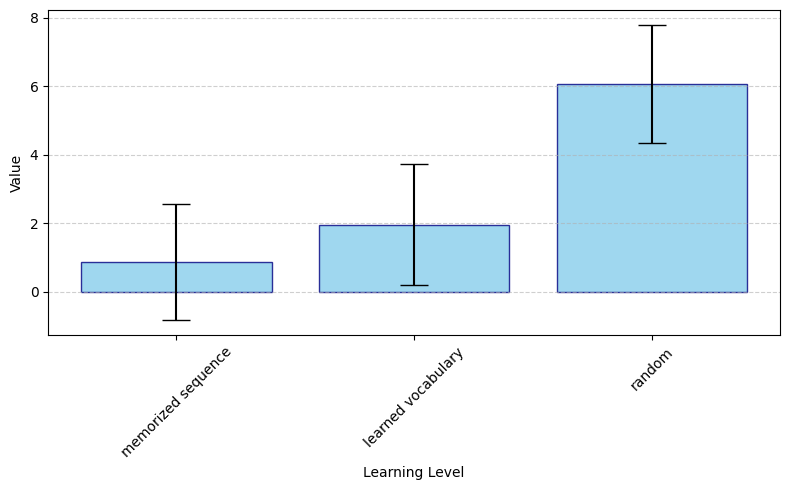

In [31]:
from utils.misc import bootstrapped_mean_and_ci
from evaluation.pfa_evaluation import compute_losses_per_level, compute_losses_per_level_statistics

losses = ('next_token_losses', latent_entropy_key, latent_losses_key, phi_losses_key)

losses_vs_learning_levels = compute_losses_per_level(datapoints,filter_out_spaces=False,losses=losses,levels=included_levels)
losses_vs_learning_levels_statistics = compute_losses_per_level_statistics(losses_vs_learning_levels, losses=losses, levels=included_levels)
plot_binned_error_bars(included_levels, losses_vs_learning_levels_statistics[latent_entropy_key])

# Sequence latent losses

In [32]:
latent_chars = colorize_chars(*normalize_data(datapoint, latent_losses_key ,string_len, True))
display(HTML(latent_chars))

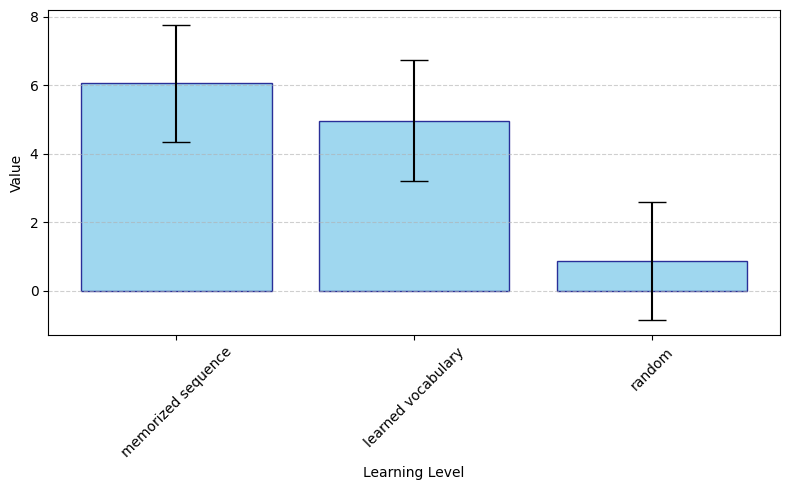

In [33]:
plot_binned_error_bars(included_levels, losses_vs_learning_levels_statistics[latent_losses_key])

# Sequence PHi loss

In [34]:
phi_chars = colorize_chars(*normalize_data(datapoint, phi_losses_key ,string_len, True))
display(HTML(phi_chars))

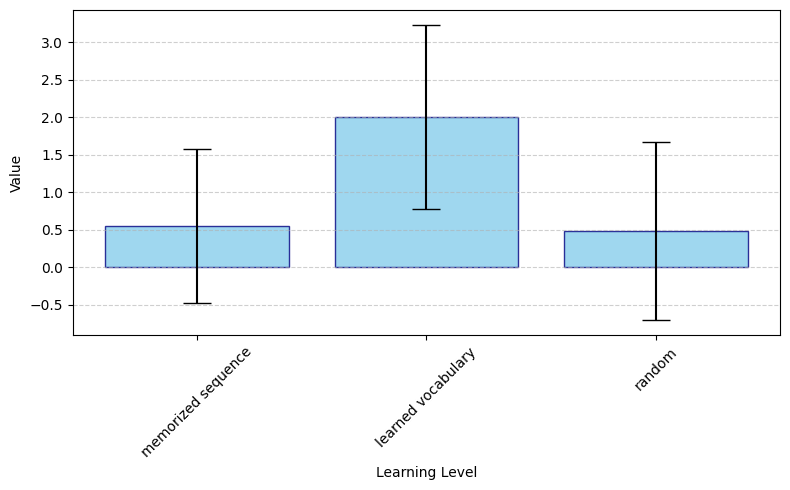

In [35]:
plot_binned_error_bars(included_levels, losses_vs_learning_levels_statistics[phi_losses_key])

## Sequence NLL 

In [36]:
phi_chars = colorize_chars(*normalize_data(datapoint, 'next_token_losses',string_len))
display(HTML(phi_chars))

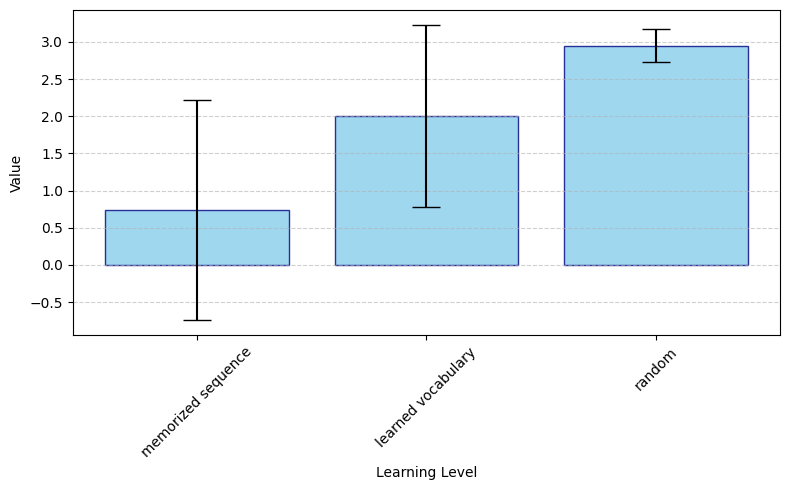

In [20]:
plot_binned_error_bars(included_levels, losses_vs_learning_levels_statistics['next_token_losses'])

# PHi Losses vs NLL by Learning Level

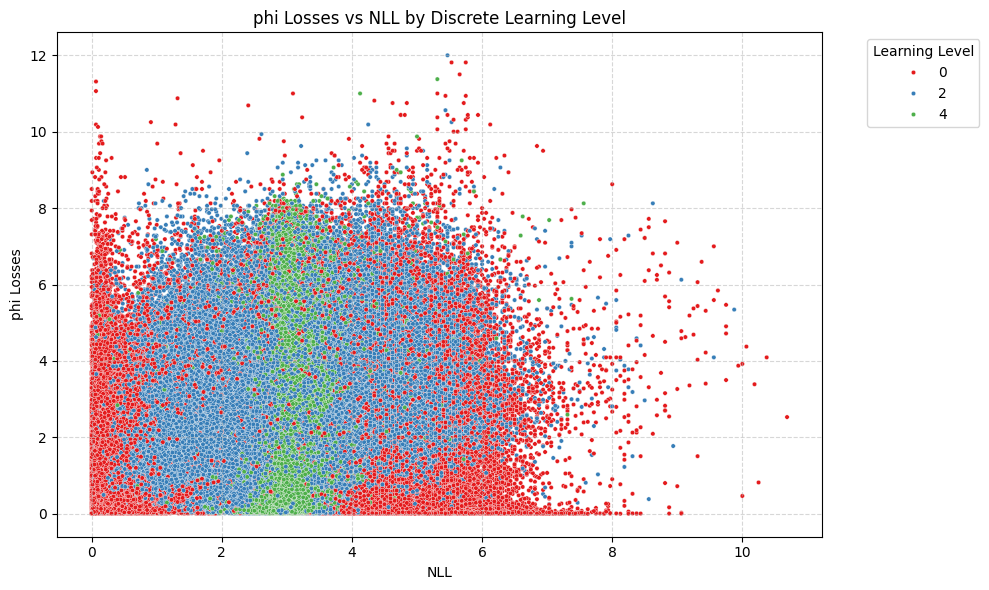

In [50]:
phi_losses_list = []
learning_level_list = []
nll_list = []
latent_entropy_list = []
latent_losses_list = []
for i in datapoints:
    phi_losses_list.extend(i[phi_losses_key][:])
    learning_level_list.extend(i['learning_level'][:])
    nll_list.extend(i['next_token_losses'][:])
    latent_entropy_list.extend(i[latent_entropy_key][:])
    latent_losses_list.extend(i[latent_losses_key][:])

df = pd.DataFrame({
    'phi_losses': phi_losses_list,
    'nll': nll_list,
    'entropy': latent_entropy_list,
    'latent_loss': latent_losses_list,
    'learning_level': learning_level_list
})
df_filtered = df[df['learning_level'] != -1].copy()
group_map = {
    0: 'Memorized', 1: 'Memorized',
    2: 'Learned', 3: 'Learned',
    4: 'Random',
}
df_filtered['fused_group'] = df_filtered['learning_level'].map(group_map)
stats = df_filtered.groupby('fused_group').agg({
    'phi_losses': ['mean', 'std'],
    'nll': ['mean', 'std'],
    'entropy': ['mean','std'],
    'latent_loss': ['mean', 'std'],
}).reset_index()
stats.columns = ['group', 'phi_mean', 'phi_std', 'nll_mean', 'nll_std', 'entropy_mean', 'entropy_std', 'latent_loss_mean', 'latent_loss_std']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='nll', y='phi_losses', hue='learning_level', palette='Set1', s=10)

plt.xlabel('NLL')
plt.ylabel('phi Losses')
plt.title('phi Losses vs NLL by Discrete Learning Level')
plt.legend(title='Learning Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# PHi losses vs entropy

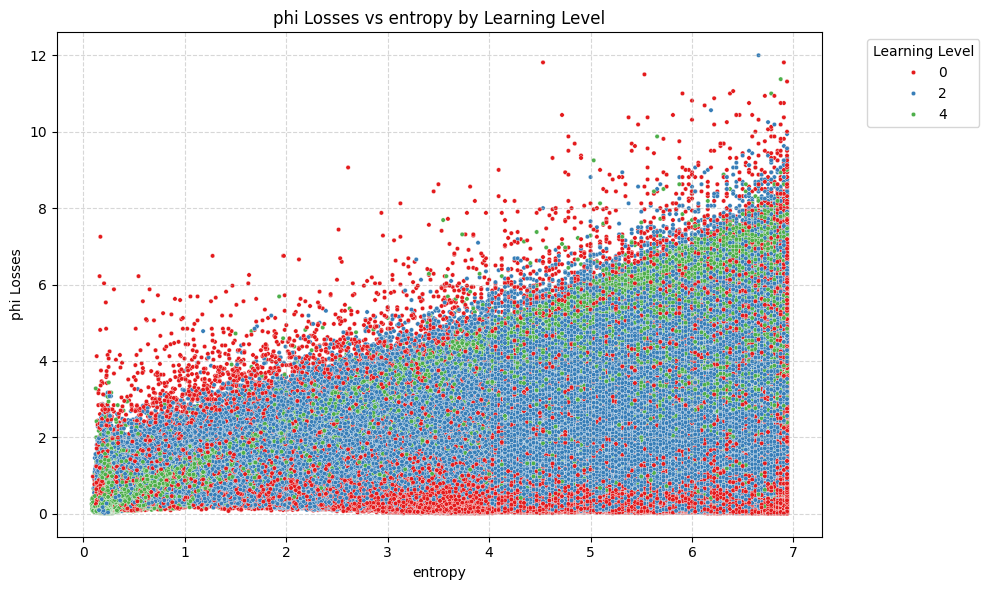

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='latent_loss', y='phi_losses', hue='learning_level', palette='Set1', s=10)

plt.xlabel('entropy')
plt.ylabel('PHi Losses')
plt.title('PHi Losses vs Entropy by Learning Level')
plt.legend(title='Learning Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

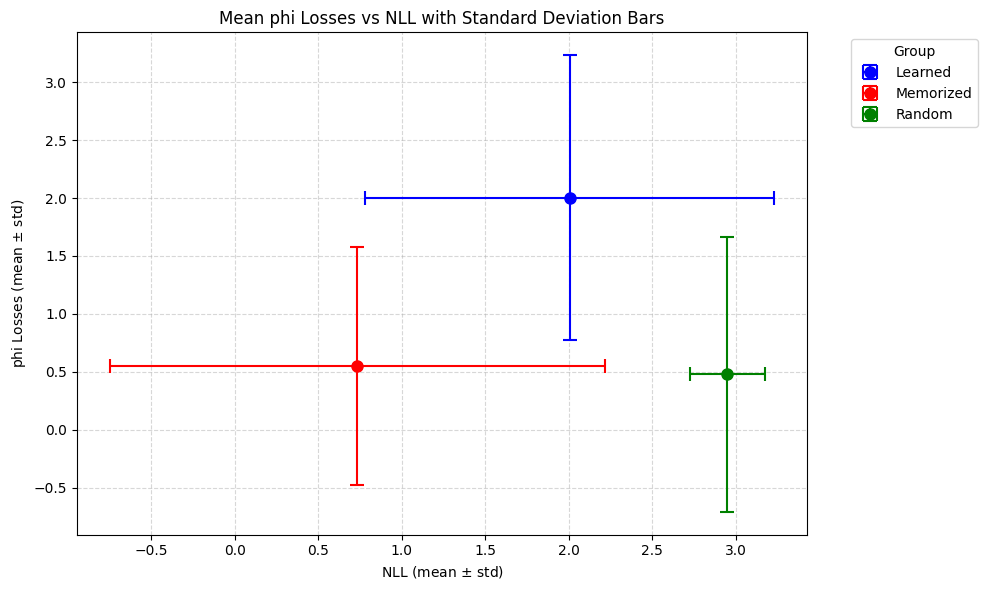

In [51]:
plt.figure(figsize=(10, 6))

# Define a color map for the groups to stay consistent
colors = {'Memorized': 'red', 'Learned': 'blue', 'Random': 'green'}

# Iterate through the stats DataFrame to plot each group point with error bars
for i, row in stats.iterrows():
    plt.errorbar(
        x=row['nll_mean'], 
        y=row['phi_mean'], 
        xerr=row['nll_std'], 
        yerr=row['phi_std'], 
        fmt='o',             # 'o' displays a point for the mean
        capsize=5,           # Adds horizontal/vertical caps to the ends of the bars
        markersize=8,        # Size of the mean point
        label=row['group'],  # Label for the legend
        color=colors.get(row['group'], None), # Match colors if defined
        elinewidth=1.5,      # Thickness of the error bar lines
        capthick=1.5
    )

plt.xlabel('NLL (mean $\pm$ std)')
plt.ylabel('phi Losses (mean $\pm$ std)')
plt.title('Mean phi Losses vs NLL with Standard Deviation Bars')

# Place legend outside or inside
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

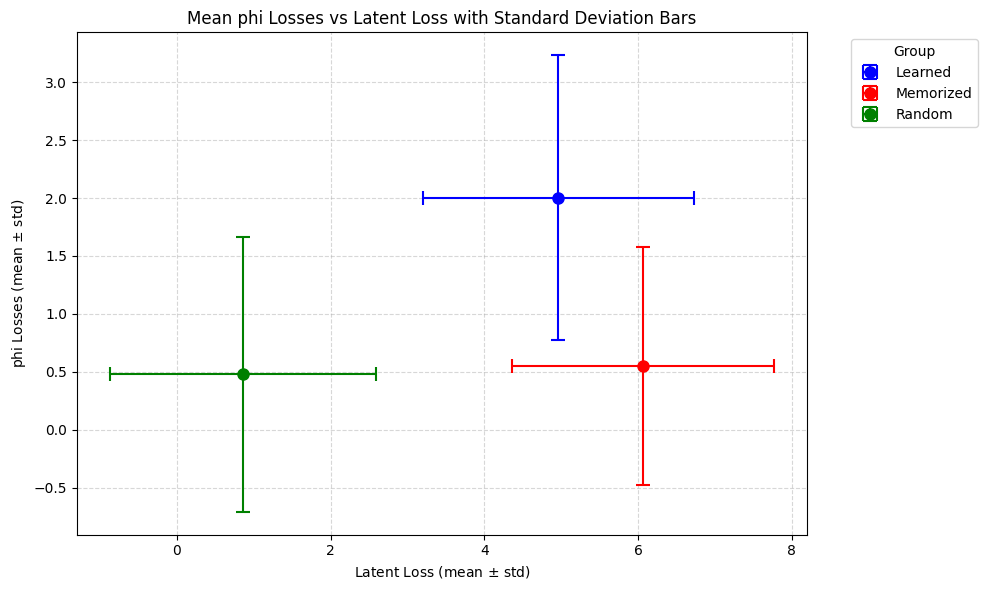

In [53]:
plt.figure(figsize=(10, 6))

# Define a color map for the groups to stay consistent
colors = {'Memorized': 'red', 'Learned': 'blue', 'Random': 'green'}

# Iterate through the stats DataFrame to plot each group point with error bars
for i, row in stats.iterrows():
    plt.errorbar(
        x=row['latent_loss_mean'], 
        y=row['phi_mean'], 
        xerr=row['latent_loss_std'], 
        yerr=row['phi_std'], 
        fmt='o',             # 'o' displays a point for the mean
        capsize=5,           # Adds horizontal/vertical caps to the ends of the bars
        markersize=8,        # Size of the mean point
        label=row['group'],  # Label for the legend
        color=colors.get(row['group'], None), # Match colors if defined
        elinewidth=1.5,      # Thickness of the error bar lines
        capthick=1.5
    )

plt.xlabel('Latent Loss (mean $\pm$ std)')
plt.ylabel('phi Losses (mean $\pm$ std)')
plt.title('Mean phi Losses vs Latent Loss with Standard Deviation Bars')

# Place legend outside or inside
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

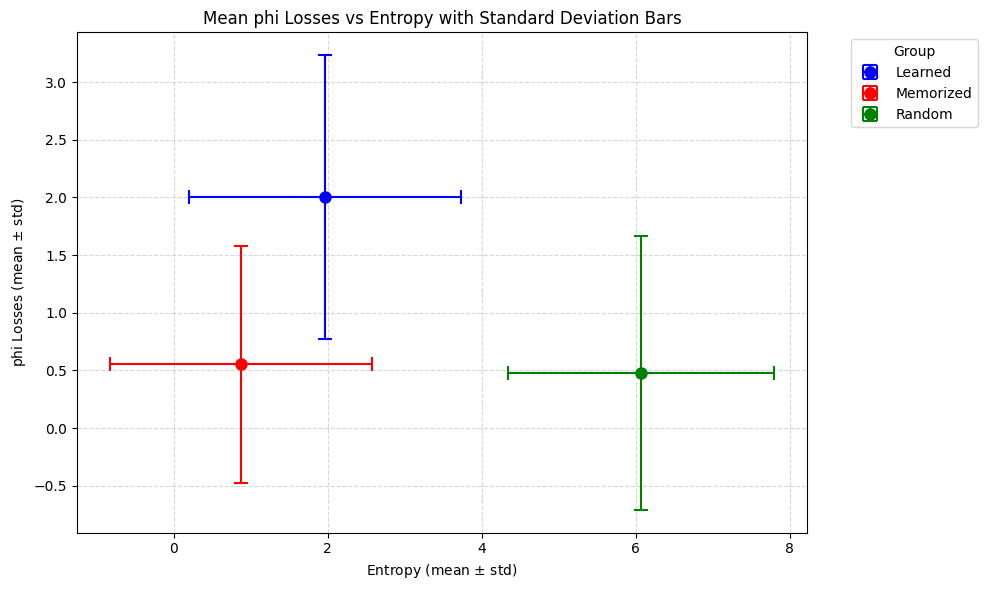

In [54]:
plt.figure(figsize=(10, 6))

# Define a color map for the groups to stay consistent
colors = {'Memorized': 'red', 'Learned': 'blue', 'Random': 'green'}

# Iterate through the stats DataFrame to plot each group point with error bars
for i, row in stats.iterrows():
    plt.errorbar(
        x=row['entropy_mean'], 
        y=row['phi_mean'], 
        xerr=row['entropy_std'], 
        yerr=row['phi_std'], 
        fmt='o',             # 'o' displays a point for the mean
        capsize=5,           # Adds horizontal/vertical caps to the ends of the bars
        markersize=8,        # Size of the mean point
        label=row['group'],  # Label for the legend
        color=colors.get(row['group'], None), # Match colors if defined
        elinewidth=1.5,      # Thickness of the error bar lines
        capthick=1.5
    )

plt.xlabel('Entropy (mean $\pm$ std)')
plt.ylabel('phi Losses (mean $\pm$ std)')
plt.title('Mean phi Losses vs Entropy with Standard Deviation Bars')

# Place legend outside or inside
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
from modules.architectures import TransformerDecoder
from typing import Optional, List, Tuple, Optional, Callable
# from torchtune.generation._generation import get_causal_mask_from_padding_mask
from torchtune.generation import generate_next_token
from torchtune.generation._generation import update_stop_tokens_tracker, get_position_ids_from_padding_mask

def get_causal_mask_from_padding_mask(
    padding_mask: torch.Tensor, target_seq_len: Optional[int] = None
) -> torch.Tensor:
    bsz, seq_len = padding_mask.shape
    target_seq_len = seq_len if target_seq_len is None else target_seq_len

    if target_seq_len < seq_len:
        # return None
        raise AssertionError(
            "target_seq_len cannot be shorter than the sequence length of the padding mask."
        )

    mask = torch.tril(
        torch.ones(seq_len, target_seq_len, device=padding_mask.device, dtype=bool),
        diagonal=0,
    ).repeat(bsz, 1, 1)
    mask.narrow(2, 0, seq_len).mul_(padding_mask[:, None, :].expand(-1, seq_len, -1))
    mask.diagonal(dim1=1, dim2=2).copy_(torch.Tensor([True]))
    return mask

@torch.inference_mode()
def generate_fn(
    model: TransformerDecoder,
    prompt: torch.Tensor,
    *,
    max_generated_tokens: int,
    pad_id: int = 0,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    stop_tokens: Optional[List[int]] = None,
    rng: Optional[torch.Generator] = None,
    custom_generate_next_token: Optional[Callable] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    prompt = prompt.view(1, -1) if prompt.ndim == 1 else prompt

    if custom_generate_next_token is None:
        custom_generate_next_token = generate_next_token

    bsz, prompt_length = prompt.size()
    total_response_length = prompt_length + max_generated_tokens

    generated_tokens = prompt.clone()
    incremental_decoding = model.caches_are_enabled()

    # grab the correct max_seq_len to generate full causal masks/position ids
    # this is the model's max cache len if incremental decoding, or the sequence
    # length otherwise
    max_seq_len = (
        total_response_length
        if not incremental_decoding
        else model.decoder_max_cache_seq_len
    )

    padding_masks = generated_tokens != pad_id

    # padding_masks = padding_masks[total_response_length < max_seq_len]

    if not padding_masks.all():
        # we have padding in the prompt due to varying-length sequences in a batch
        # extend padding masks out to the correct seq len
        padding_masks = torch.nn.functional.pad(
            padding_masks, (0, max_generated_tokens), value=True
        )

        # generate the full causal mask for the whole padding mask with padding ignored
        masks = get_causal_mask_from_padding_mask(
            padding_masks, 
            target_seq_len=max_seq_len
        )

        # right-shift position IDs to account for padding
        input_pos = get_position_ids_from_padding_mask(padding_masks)
    else:
        # just use a regular causal mask if there is no padding
        masks = torch.tril(
            torch.ones(
                total_response_length,
                max_seq_len,
                dtype=torch.bool,
                device=prompt.device,
            )
        ).unsqueeze(0)
        input_pos = torch.arange(
            0, total_response_length, device=generated_tokens.device
        ).unsqueeze(0)

    if incremental_decoding:
        # if KV-caches are enabled, we need a causal mask of shape [bsz, prompt_length, max_cache_len]
        # to match the key/value cache tensor shapes
        curr_masks = masks[:, :prompt_length]
    else:
        # otherwise the causal mask is shape [bsz, prompt_length, prompt_length] because key/value
        # tensors are of identical shape to the prompt
        curr_masks = masks[:, :prompt_length, :prompt_length]

    q = None
    if rng is not None:
        q = torch.empty(
            (bsz, model.tok_embeddings.num_embeddings), device=prompt.device
        ).exponential_(1, generator=rng)
    tokens, generated_logits = generate_next_token(
        model,
        input_pos=input_pos[:, :prompt_length].squeeze(),
        mask=curr_masks,
        x=prompt,
        temperature=temperature,
        top_k=top_k,
        q=q,
    )

    generated_tokens = torch.cat([generated_tokens, tokens], dim=-1)

    curr_pos = prompt_length

    # keeps track at a high level if we've already hit a stop token in a sequence so we can early stop
    stop_token_reached = torch.zeros(bsz, dtype=torch.bool, device=prompt.device)
    stop_tokens = (
        torch.tensor(stop_tokens, device=prompt.device, dtype=tokens.dtype)
        if stop_tokens
        else None
    )

    # everything in stop_token_mask starts as 1s, and we'll set them to 0 for sequences
    # that already hit a stop token
    stop_token_mask = torch.ones(
        (bsz, prompt_length + 1), dtype=torch.int32, device=prompt.device
    )

    # stop early if we reach a stop token in every seq
    if stop_tokens is not None:
        stop_token_reached = update_stop_tokens_tracker(
            tokens, stop_tokens, stop_token_reached
        )
        if stop_token_reached.all().item():
            return generated_tokens, generated_logits

    for _ in range(max_generated_tokens - 1):
        # update stop_token_mask if we reached a stop token in a previous step
        # by appending the logical not of stop_token_reached to the end of the mask
        # reshaped to be bsz first
        if stop_tokens is not None:
            stop_token_mask = torch.cat(
                [stop_token_mask, ~stop_token_reached.reshape(bsz, 1)], dim=-1
            )

        # if incremental decoding is enabled, we can use the current position
        # otherwise, we take the whole sequence up to the current position
        if incremental_decoding:
            curr_input_pos = input_pos[:, curr_pos]
            curr_masks = masks[:, curr_pos, None, :]
        else:
            tokens = generated_tokens.clone()
            curr_input_pos = input_pos[:, : curr_pos + 1]
            curr_masks = masks[:, : curr_pos + 1, : curr_pos + 1]

        q = None
        if rng is not None:
            q = torch.empty(
                (bsz, model.tok_embeddings.num_embeddings), device=prompt.device
            ).exponential_(1, generator=rng)
        tokens, logits = custom_generate_next_token(
            model,
            input_pos=curr_input_pos,
            x=tokens.clone(),
            mask=curr_masks,
            temperature=temperature,
            top_k=top_k,
            q=q,
        )
        generated_tokens = torch.cat([generated_tokens, tokens], dim=-1)
        curr_pos += 1
        if incremental_decoding:
            generated_logits = torch.cat([generated_logits, logits], dim=1)
        else:
            generated_logits = logits

        if stop_tokens is not None:
            stop_token_reached = update_stop_tokens_tracker(
                tokens, stop_tokens, stop_token_reached
            )
            if stop_token_reached.all():
                break

    # mask out generated tokens in seqs that already hit a stop token
    if stop_tokens is not None:
        generated_tokens *= stop_token_mask
        # generated_logits *= stop_token_mask[:, :-1, None]        
        generated_logits  = generated_logits *stop_token_mask[:, -generated_logits.shape[1]:, None]

    return generated_tokens, generated_logits

In [22]:
from torchtune import generation
from torchtune.modules import delete_kv_caches
from evaluation.custom_generation import generate_next_token_only_lowercase
from evaluation.pfa_evaluation import recognized_prefix_length


def generate(prompt_tokens,
             recipe,
             max_new_tokens=100,
             return_logits=False,
             temperature=0.6,
             top_k=300,
             stop_tokens=[],
             custom_generate_next_token=None):
    if not type(prompt_tokens[0]) == list:
        prompt_tokens = [prompt_tokens]
    for i, prompt in enumerate(prompt_tokens):
        if prompt[-1] == recipe._tokenizer.eos_id:
            # print("remove eos")
            prompt_tokens[i] = prompt[:-1]
    max_len = max([len(p) for p in prompt_tokens])
    
    # fill with zeros
    prompt_tokens = [p + [0] * (max_len - len(p)) for p in prompt_tokens]
    
    prompt = torch.tensor(prompt_tokens, dtype=torch.int, device=recipe._device)

    generated_tokens, generated_logits = generate_fn(
                model=recipe._model,
                prompt=prompt,
                max_generated_tokens=max_new_tokens,
                pad_id=recipe._tokenizer.pad_id,
                temperature=temperature,
                top_k=top_k,
                stop_tokens=stop_tokens,
                custom_generate_next_token=custom_generate_next_token,
            )
    generated_tokens = generated_tokens[:, 1:]

    return_dicts = []
    # generated_tokens = generated_tokens[:, prompt.shape[1]-1:]
    for i in range(generated_tokens.shape[0]):
        gen_tok = generated_tokens[i]
        gen_log = generated_logits[i]
        mask = gen_tok == recipe._tokenizer.pad_id
        gen_tok = gen_tok[~mask]
        gen_log = gen_log[~mask[-gen_log.shape[0]:].to(gen_log.device)]
        decoded_tokens = recipe._tokenizer.decode(gen_tok.tolist())
        #selected_log_probs = gen_log.log_softmax(dim=-1)[range(len(gen_tok)), gen_tok.to(gen_log.device)]
        return_dict = {
            "decoded_tokens": decoded_tokens,
            "generated_tokens": gen_tok,
            "neg_log_probs": gen_log,
        }
        return_dicts.append(return_dict)
    return return_dicts

    # generated_tokens: [bsz x seq_length]
    # generated_logits: [bsz x seq_length x vocab_size]

    selected_neg_log_probs = generated_logits.log_softmax(dim=-1)[
        range(len(generated_tokens[1:])), generated_tokens[1:]
    ]

    decoded_tokens = recipe._tokenizer.decode(generated_tokens.tolist())
    return_dict = {
        "decoded_tokens": decoded_tokens,
        "generated_tokens": generated_tokens,
        "neg_log_probs": selected_neg_log_probs,
    }
    if return_logits:
        return_dict["logits"] = generated_logits
    return return_dict

def recognized_prefix_length(M: np.ndarray | list, tokens: list[int]) -> (int, bool):
    n = M.shape[0]  # number of states
    # Q_i will be stored as a NumPy 1D array of valid states
    Q_current = np.arange(n)  # We can start from any state: Q_0 = {0, 1, ..., n-1}

    # We will track how many tokens we've successfully consumed
    consumed = 0

    for token in tokens:
        # For each state p in Q_current, we check if there's a q with M[p, q] == token
        next_states = []

        for p in Q_current:
            # Find all q such that M[p,q] == token
            # np.where(...) returns tuple (array_of_indices,), so we take [0]
            q_candidates = np.where(M[p, :] == token)[0]
            next_states.extend(q_candidates)

        # Keep unique states (we don't want duplicates)
        next_states = np.unique(next_states)

        if len(next_states) == 0:
            # No valid transition for this token
            return consumed, False

        # Update Q_current for the next iteration
        Q_current = next_states
        consumed += 1  # We matched one more token

    # If we exit the loop without breaks, we matched all tokens
    return consumed, True

In [23]:
from tqdm import tqdm 

def evaluate_language_generation_length(recipe,
                                        num_samples=1000,
                                        batch_size=100,
                                       max_new_tokens=100):
    kwargs = dict(recipe.cfg.dataset)
    kwargs.pop("_component_")
    kwargs["tokenizer"] = tokenizer
    kwargs["word_perturbation_rate"] = 0.
    kwargs["token_perturbation_rate"] = 0.
    kwargs["sequences_per_language_min"] = 40
    kwargs["sequences_per_language_max"] = 41
    kwargs["included_learning_levels"] = [1,3]
    kwargs["max_sample_length"] = 1800
    dataset = learning_levels_pfa_dataset(**kwargs)

    char_to_idx = {c: i for i, c in enumerate(dataset.letters)}

    with recipe._device:
        recipe._model.setup_caches(
            batch_size=batch_size,
            dtype=recipe._dtype,
            decoder_max_seq_len=kwargs["max_sample_length"]+max_new_tokens,
        )
    previous_num_chunks = recipe._model.num_output_chunks
    recipe._model.num_output_chunks = 0

    correct_lengths = []
        
    for i in tqdm(range(0, num_samples, batch_size)):
        recipe._model.reset_caches()
        recipe._model.self_prediction_losses.reset()
        tokens = []
        transition_symbols = []
        for j in range(batch_size):
            sample = dataset[i]
            tokens.append(sample['tokens'])
            if sum(sample['new_language']) > 1:
                transition_symbols.append( [ np.array(i) for i in sample['_transition_symbols']  ])
            else:
                transition_symbols.append( [np.array(i) for i in sample['_transition_symbols']][0] )
        generated_sequences = generate(tokens,
                     recipe=recipe,
                     max_new_tokens=max_new_tokens,
                     top_k=18,
                     stop_tokens=[32],
                     custom_generate_next_token=generate_next_token_only_lowercase)
        for j, d in enumerate(generated_sequences):
            decoded_tokens = d['decoded_tokens']
            # print('decoded tokens', decoded_tokens[:-len(tokens[j])])
            sequences = decoded_tokens.split(' ')
            sequences_np = [np.array([char_to_idx[c] if c in char_to_idx else 25 for c in s]) for s in sequences]
            current_symbols = transition_symbols[j]

            for seq_i, seq in enumerate(sequences_np):
                # if isinstance(current_symbols, list):
                #     len_correct_old = -float('inf')
                #     for l_symbols in current_symbols:
                #         len_correct, accepted = recognized_prefix_length(l_symbols, seq)
                #         if accepted and len_correct > len_correct_old:
                #             len_correct_old = len_correct
                #             break
                # else:
                len_correct, accepted = recognized_prefix_length(current_symbols, seq)
                
                if seq_i == len(sequences_np) - 1:
                    # print(seq)
                    # print(f"{i + j + 1}/{num_samples}: {len_correct}/{len(seq)} correct")
                    correct_lengths.append(len_correct)
                else:
                    assert accepted

    correct_lengths = np.array(correct_lengths)
    ci_mean, ci_lower, ci_higher = bootstrapped_mean_and_ci(correct_lengths, num_samples=10000)

    # delete_kv_caches(recipe._model)
    recipe._model.num_output_chunks = previous_num_chunks

    return {
        "accepted_lengths": correct_lengths.tolist(),
        "mean": correct_lengths.mean(),
        "std": correct_lengths.std(),
        "std_err": correct_lengths.std() / np.sqrt(correct_lengths.size),
        "ci_mean": ci_mean,
        "ci_95": [ci_lower, ci_higher]
    }

In [24]:
evaluate_language_generation_length(recipe, 100, 4, 100)

AttributeError: 'ModuleList' object has no attribute 'setup_cache'